# 第三章

## 线性回归
线性回归是对n维输入的加权，外加偏差
使用平方损失来衡量预测值和真实值的差异
线性回归有显示解
线性回归可以看做是单层神经网络

当输入包含$d$个特征时，将预测结果$\hat{y}$ (通常使用"尖
角"符号表示$y$的估计值)表示为：

$$\hat{y}=w_1x_1+\ldots+w_dx_d+b.$$
将所有特征放到向量$\mathbf{x}\in\mathbb{R}^d$中，并将所有权重放到向量$\mathbf{w}\in\mathbb{R}^d$中，可以用
点积形式来简洁地表达模型：
$$\hat{y}=\mathbf{w}^\top\mathbf{x}+b.$$

损失函数（loss function）能够量化目标的实际值与预测值之间的差距。
回归问题中最常用的损失函数是平方误差函数。 当样本$i$的预测值为$\hat{y}^{(i)}$,
其相应的真实标签为$y^{(i)}$时，平方误差可以定义为以下公式：
$$l^{(i)}(\mathbf{w},b)=\frac12\left(\hat{y}^{(i)}-y^{(i)}\right)^2.$$

通常会在每次需要计算更新的时候随机抽取一小批样本,这种变体叫做小批量随机梯度下降（minibatch stochastic gradient descent）。
批量大小和学习率的值可以调整但不在训练过程中更新,称为超参数（hyperparameter）。调参（hyperparameter tuning）是选择超参数的过程。超参数通常是我们根据训练迭代结果来调整的， 而训练迭代结果是在独立的验证数据集（validation dataset）上评估得到的。  
矢量化代码通常会带来数量级的加速。  
每个输入都与每个输出相连， 我们将这种变换称为全连接层（fully-connected layer）或称为稠密层（dense layer）。  
最小化目标函数和执行极大似然估计等价。  
线性回归模型是一个简单的神经网络。  


## 线性回归的从零开始实现

In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [2]:
#生成数据集
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [3]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-0.1888, -1.6332]) 
label: tensor([9.3758])


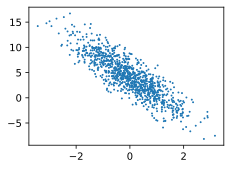

In [4]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [5]:
#读取数据集
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [6]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.4779, -0.2009],
        [ 1.0766,  0.6127],
        [-0.4276,  1.0437],
        [-0.2544,  0.0940],
        [ 1.6553, -0.6610],
        [ 0.1711, -1.1424],
        [-2.2354,  0.2189],
        [ 1.2615, -0.3806],
        [-0.0594,  1.8060],
        [ 1.3297,  0.4862]]) 
 tensor([[ 5.8404],
        [ 4.3000],
        [-0.2048],
        [ 3.3631],
        [ 9.7539],
        [ 8.4199],
        [-1.0248],
        [ 8.0223],
        [-2.0614],
        [ 5.1916]])


In [7]:
#初始化模型参数
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [8]:
#定义模型
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [9]:
#定义损失函数
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [10]:
#定义优化算法
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [11]:
#训练
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.035376
epoch 2, loss 0.000136
epoch 3, loss 0.000053


In [12]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([0.0004, 0.0002], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0005], grad_fn=<RsubBackward1>)


## 线性回归的简洁实现

In [13]:
#生成数据集
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [14]:
#读取数据集
def load_array(data_arrays, batch_size, is_train=True):  #@save
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)#shuffle是否打乱顺序

batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [15]:
next(iter(data_iter))

[tensor([[ 0.2295, -0.5794],
         [-0.3900, -0.1600],
         [ 0.7788, -0.1802],
         [-1.0463,  1.0305],
         [ 0.7588,  0.1122],
         [-2.1639, -3.0656],
         [-1.0304, -0.8789],
         [ 0.8396, -0.4372],
         [ 0.2850,  1.1157],
         [-0.1202, -0.6885]]),
 tensor([[ 6.6371],
         [ 3.9483],
         [ 6.3816],
         [-1.4072],
         [ 5.3377],
         [10.3246],
         [ 5.1301],
         [ 7.3701],
         [ 0.9935],
         [ 6.3126]])]

In [16]:
#定义模型
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

In [17]:
#初始化模型参数
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [18]:
#定义损失函数
loss = nn.MSELoss()

In [19]:
#定义优化算法
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [20]:
#训练
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X) ,y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000203
epoch 2, loss 0.000103
epoch 3, loss 0.000103


In [21]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([0.0006, 0.0001])
b的估计误差： tensor([0.0005])


在PyTorch中，data模块提供了数据处理工具，nn模块定义了大量的神经网络层和常见损失函数。

我们可以通过_结尾的方法将参数替换，从而初始化参数。

## softmax 回归

独热编码（one-hot encoding）：是一个向量，它的分量和类别一样多。 类别对应的分量设置为1，其他所有分量设置为0。  
softmax回归是一个单层神经网络。  
$$\hat{\mathbf{y}} = \mathrm{softmax}(\mathbf{o})\quad \text{其中}\quad \hat{y}_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$$
输出匹配概率(非负，和为1)  
softmax运算不会改变未规范化的预测$\mathbf{o}$之间的大小次序，只会确定分配给每个类别的概率。  
Softmax 和交叉熵损失
交叉熵常用来衡量两个概率的区别 $H(\mathbf{p}, \mathbf{q}) = \sum_{i} - p_{i} \log(q_{i})$  
将它作为损失
$l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{i} y_{i} \log \hat{y}_{i} = - \log \hat{y}_{y}$  
其梯度是真实概率和预测概率的区别
$\partial_{o_{i}} l(\mathbf{y}, \hat{\mathbf{y}}) = \text{softmax}(\mathbf{o})_{i} - y_{i}$
* Softmax 回归是一个多类分类模型
* 使用 Softmax 操作子得到每个类的预测置信度
* 使用交叉熵来衡量预测和标号的区别

## 图像分类数据集

In [22]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

In [23]:
#读取数据集
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式，
# 并除以255使得所有像素的数值均在0～1之间
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

100.0%


Extracting ../data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100.0%


Extracting ../data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



100.0%


Extracting ../data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100.0%

Extracting ../data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



In [24]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [25]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [26]:
def get_fashion_mnist_labels(labels):  #@save
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [27]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #@save
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 图片张量
            ax.imshow(img.numpy())
        else:
            # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

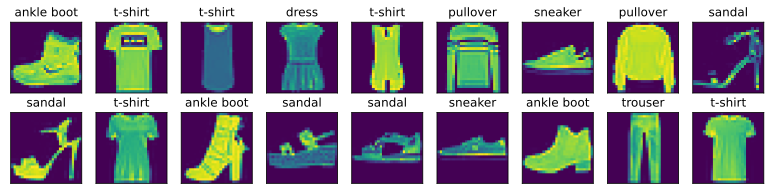

In [28]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y));

In [29]:
#读取小批量
batch_size = 256

def get_dataloader_workers():  #@save
    """使用4个进程来读取数据"""
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=get_dataloader_workers())

In [30]:
timer = d2l.Timer()
for X, y in train_iter:
    continue
f'{timer.stop():.2f} sec'

'11.24 sec'

In [31]:
#整合所有组件
def load_data_fashion_mnist(batch_size, resize=None):  #@save
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

In [32]:
train_iter, test_iter = load_data_fashion_mnist(32, resize=64)
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64


Fashion-MNIST是一个服装分类数据集，由10个类别的图像组成。将高度h像素，宽度w像素图像的形状记为h×w或（h,w）。

## softmax回归的从零开始实现

In [33]:
import torch
from IPython import display
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [34]:
#初始化模型参数
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

In [35]:
#定义softmax操作
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [36]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition  # 应用广播机制

In [37]:
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.1387, 0.1994, 0.3236, 0.1322, 0.2061],
         [0.4275, 0.0654, 0.4097, 0.0398, 0.0576]]),
 tensor([1., 1.]))

In [38]:
#定义模型
def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

In [39]:
#定义损失函数
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]

tensor([0.1000, 0.5000])

In [40]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

In [41]:
#分类精度
def accuracy(y_hat, y):  #@save
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

In [42]:
accuracy(y_hat, y) / len(y)

0.5

In [43]:
def evaluate_accuracy(net, data_iter):  #@save
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式
    metric = Accumulator(2)  # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [44]:
class Accumulator:  #@save
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [45]:
evaluate_accuracy(net, test_iter)

0.1079

In [46]:
#训练
def train_epoch_ch3(net, train_iter, loss, updater):  #@save
    """训练模型一个迭代周期"""
    # 将模型设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 训练损失总和、训练准确度总和、样本数
    metric = Accumulator(3)
    for X, y in train_iter:
        # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]

In [47]:
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [48]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    """训练模型"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

In [49]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

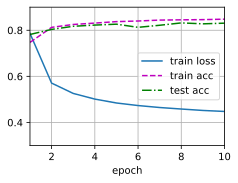

In [50]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

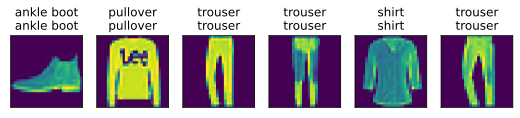

In [51]:
#预测
def predict_ch3(net, test_iter, n=6):  #@save
    """预测标签"""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)

## softmax回归的简洁实现

In [53]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [54]:
#初始化模型参数
# PyTorch不会隐式地调整输入的形状。在线性层前定义了展平层（flatten），来调整网络输入的形状
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

In [55]:
loss = nn.CrossEntropyLoss(reduction='none')

In [56]:
#优化算法
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

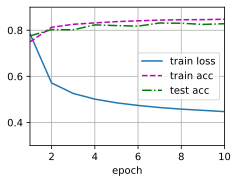

In [57]:
#训练
num_epochs = 10
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)